In [ ]:
--The Simple Short Term Memory implementation is of checkpointer only that is already done with postgres
  which works with production level


Trimming is based on assumption like to Continue the conversation user we need to have
last n tokens memory so that LLm will answer it and not to send whole messages history
because of context window of LLM. But in real World scenario previous messages could also help 
so for including we use summarization of previous messages plus this last n tokens

In [13]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
import os

In [14]:
load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")

In [15]:
llm = ChatOpenAI(
    model="deepseek/deepseek-r1-0528:free",
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

In [ ]:
def call_model(state: MessagesState):
    
    messages = trim_messages(
        state["messages"],
        strategy = "last",                      
        token_counter = count_tokens_approximately,
        max_tokens = 200
        #it takes last 200 messages when its 200 tokens limit exceeded
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)

    return {"messages": [response]}

In [17]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [18]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

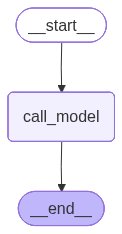

In [19]:
graph

In [21]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is yug."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 74
Hi, my name is Nitish.
Hi Nitish! 👋 It's nice to meet you. I'm here to help with anything you need — whether it's answering questions, explaining concepts, solving problems, or just chatting. What can I do for you today? 😊
Hi, my name is yug.


"Oh! Nice to meet you too, Yug! 😊  \nWhether you're here with a question, need help with something, or just want to chat—I'm all ears! What brings you here today?"

In [22]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I testing Trimming in LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 132
Hi, my name is Nitish.
Hi Nitish! 👋 It's nice to meet you. I'm here to help with anything you need — whether it's answering questions, explaining concepts, solving problems, or just chatting. What can I do for you today? 😊
Hi, my name is yug.
Oh! Nice to meet you too, Yug! 😊  
Whether you're here with a question, need help with something, or just want to chat—I'm all ears! What brings you here today?
I testing Trimming in LangGraph.


'That\'s awesome, Yug! 😄 Testing trimming in LangGraph is a great way to understand how state management works in stateful LLM applications. Here\'s a quick rundown to help with your test:\n\n### Key Concepts for Trimming in LangGraph:\n1. **State Management**  \n   LangGraph maintains a state object that evolves across steps. Trimming removes unnecessary historical state data to reduce memory/compute.\n\n2. **Trimming Methods**  \n   - **Manual Trimming**: Explicitly prune state in `nodes` using Python list/dict operations.  \n   - **Automatic Trimming**: Use built-in `StateGraph` features (like `add_edge` conditions) to auto-trim irrelevant history.\n\n3. **When to Trim**  \n   Trim when:  \n   - State exceeds token/memory limits  \n   - Irrelevant context accumulates  \n   - After critical decision points (e.g., agent tool selection)\n\n### Simple Example Snippet:\n```python\nfrom langgraph.graph import StateGraph, END\n\n# Define state structure\nclass AgentState(TypedDict):\n    h

In [23]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'Short-term memory (STM) is your brain\'s **temporary "holding area" for a small amount of information you are actively aware of and processing right now.** Think of it like a mental clipboard or sticky note.\n\nHere are its key characteristics:\n\n1.  **Limited Capacity:** It can only hold a small number of items at once.\n    *   **Miller\'s "Magic Number":** George Miller\'s classic research suggested the capacity is **7 ± 2 items** (so roughly 5 to 9). This could be digits, words, letters, or simple concepts.\n    *   **Chunking:** You can overcome this limit slightly by "chunking" information. For example, remembering the phone number 555-1212 as "555" and "1212" (two chunks) instead of seven separate digits.\n\n2.  **Brief Duration:** Information fades very quickly if not actively maintained.\n    *   **Approximately 15-30 seconds:** Without rehearsal (repeating it mentally), information decays and is lost within seconds. The Peterson and Peterson experiment demonstrated this dec

In [24]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my Name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my Name?


"I don't know your name! 😊  \nAs an AI, I don't have access to personal information about you unless you choose to share it.  \n\nIf you'd like, you can tell me your name, and I'll happily use it in our conversation! What should I call you?"

In [25]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hi Nitish! 👋 It's nice to meet you. I'm here to help with anything you need — whether it's answering questions, explaining concepts, solving problems, or just chatting. What can I do for you today? 😊
------------------------------------------------------------------------------------------------------------------------
Hi, my name is yug.
------------------------------------------------------------------------------------------------------------------------
Oh! Nice to meet you too, Yug! 😊  
Whether you're here with a question, need help with something, or just want to chat—I'm all ears! What brings you here today?
------------------------------------------------------------------------------------------------------------------------
I testing Trimming in LangGraph.
-------------------------------------------------------------------------------